In [1]:
# Load raw ARSO weather file and inspect the structure.

import pandas as pd
weather = pd.read_csv("../data/raw/arso_temp_ljubljana_bezigrad_2025.csv")
print(weather.head())
print(weather.columns.tolist())

  station id        station name       valid  povp. dnevna T [°C]
0      _1895  Ljubljana Bežigrad  2025-01-01                  3.7
1      _1895  Ljubljana Bežigrad  2025-01-02                  6.2
2      _1895  Ljubljana Bežigrad  2025-01-03                  1.6
3      _1895  Ljubljana Bežigrad  2025-01-04                 -2.2
4      _1895  Ljubljana Bežigrad  2025-01-05                  3.9
['station id', ' station name', ' valid', 'povp. dnevna T [°C]']


In [2]:
# Strip spaces from column names.
# This removes leading and trailing spaces, which helps avoid KeyError later.

weather.columns = weather.columns.str.strip()
print(weather.columns.tolist())

['station id', 'station name', 'valid', 'povp. dnevna T [°C]']


In [3]:
# Rename columns, convert data types, keep only date and temperature,
# drop invalid rows, sort by date, and save cleaned weather data.

weather = weather.rename(columns={
    "valid": "date",
    "povp. dnevna T [°C]": "temp_c"
})

weather["date"] = pd.to_datetime(weather["date"], errors="coerce")
weather["temp_c"] = pd.to_numeric(weather["temp_c"], errors="coerce")

weather = weather[["date", "temp_c"]].dropna().sort_values("date")

print(weather.head())
print(weather.dtypes)
print(weather.shape)

weather.to_csv("../data/curated/arso_temp_ljubljana_bezigrad_2025_clean.csv", index=False)

        date  temp_c
0 2025-01-01     3.7
1 2025-01-02     6.2
2 2025-01-03     1.6
3 2025-01-04    -2.2
4 2025-01-05     3.9
date      datetime64[us]
temp_c           float64
dtype: object
(365, 2)


In [4]:
# Load curated ENTSO-E day-ahead price data.

da = pd.read_csv("../data/curated/da_prices_si_2025_clean.csv", parse_dates=["timestamp"])

print(da.head())
print(da.dtypes)
print(da.shape)
print(da["timestamp"].min(), da["timestamp"].max())

            timestamp  price_eur_mwh
0 2025-01-01 00:00:00         118.46
1 2025-01-01 01:00:00         129.07
2 2025-01-01 02:00:00         121.10
3 2025-01-01 03:00:00          94.28
4 2025-01-01 04:00:00          63.69
timestamp        datetime64[us]
price_eur_mwh           float64
dtype: object
(15387, 2)
2025-01-01 00:00:00 2026-01-01 00:00:00


In [5]:
# Create daily average DA prices from hourly ENTSO-E prices.

daily_da = (
    da.assign(date=da["timestamp"].dt.floor("D"))
      .groupby("date", as_index=False)["price_eur_mwh"]
      .mean()
      .rename(columns={"price_eur_mwh": "da_price_eur_mwh"})
)

print(daily_da.head())
print(daily_da.shape)

        date  da_price_eur_mwh
0 2025-01-01         88.346667
1 2025-01-02        115.057083
2 2025-01-03        118.064167
3 2025-01-04        127.643333
4 2025-01-05        107.945417
(366, 2)


In [6]:
# Save daily average DA prices to curated.

daily_da.to_csv("../data/curated/da_prices_si_2025_daily_avg.csv", index=False)

In [7]:
# Cell 7
# Merge daily average DA prices with ARSO daily temperature on date.
# Inner merge keeps only matching dates from both datasets.

merged = daily_da.merge(weather, on="date", how="inner")

print(merged.head())
print(merged.shape)
print(merged.isna().sum())

        date  da_price_eur_mwh  temp_c
0 2025-01-01         88.346667     3.7
1 2025-01-02        115.057083     6.2
2 2025-01-03        118.064167     1.6
3 2025-01-04        127.643333    -2.2
4 2025-01-05        107.945417     3.9
(365, 3)
date                0
da_price_eur_mwh    0
temp_c              0
dtype: int64


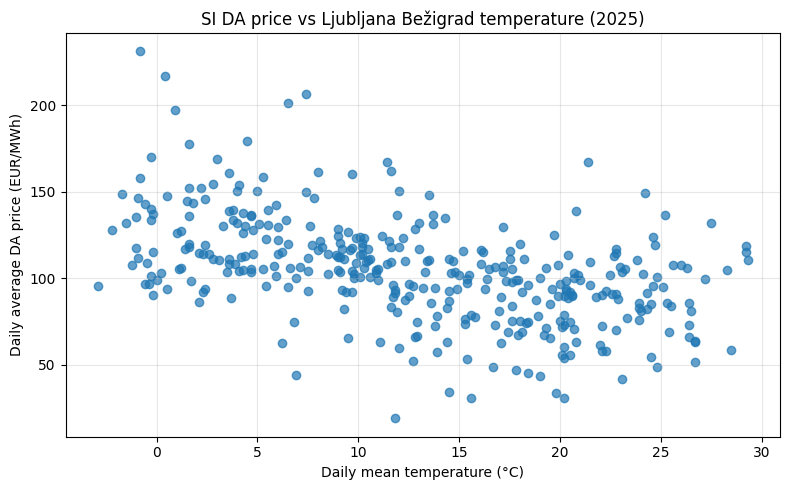

In [9]:
# Cell 8
# Create scatter plot: daily average DA price vs daily mean temperature.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(merged["temp_c"], merged["da_price_eur_mwh"], alpha=0.7)
plt.xlabel("Daily mean temperature (°C)")
plt.ylabel("Daily average DA price (EUR/MWh)")
plt.title("SI DA price vs Ljubljana Bežigrad temperature (2025)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Cell 9
# Save final merged dataset to curated.

merged.to_csv("../data/curated/da_price_vs_arso_temp_2025.csv", index=False)